In [ ]:
from sebastianM.spark_utils import SparkUtils

mongodb_connector = "org.mongodb.spark:mongo-spark-connector_2.13:10.5.0"

su = SparkUtils(
    "Videogame Recommendation Pipeline",
    "spark://spark-master:7077",
    spark_packages=mongodb_connector
)

su.spark

# Lab 7 MongoDB
**Integrantes:**
Daniel Sebastian Macias,
Guillermo Curiel 

In [ ]:
import pyspark.sql.functions as F

games_schema = SparkUtils.generate_schema([
    ("game_id",       "string"),
    ("title",         "string"),
    ("platform",      "string"),
    ("release_year",  "int"),
    ("base_score",    "double"),
    ("total_reviews", "int"),
    ("price_usd",     "double"),
    ("genres",        "array_string"),
    ("developer",     "struct", [
        ("studio",    "string"),
        ("country",   "string"),
        ("founded",   "int"),
    ]),
])

games_data = [
    ("g001", "The Legend of Zelda: Tears of the Kingdom", "Switch", 2023, 4.9, 58400, 59.99,
     ["adventure", "RPG", "open-world", "puzzle"],
     ("Nintendo EPD", "Japan", 1989)),

    ("g002", "God of War: Ragnarök", "PS5", 2022, 4.8, 42800, 69.99,
     ["action", "adventure", "story-driven", "mythology"],
     ("Santa Monica Studio", "USA", 1999)),

    ("g003", "Halo Infinite", "Xbox", 2021, 4.3, 21500, 59.99,
     ["FPS", "multiplayer", "sci-fi", "open-world"],
     ("343 Industries", "USA", 2007)),

    ("g004", "Stardew Valley", "PC", 2016, 4.7, 95200, 14.99,
     ["simulation", "indie", "farming", "RPG"],
     ("ConcernedApe", "USA", 2012)),

    ("g005", "Elden Ring", "PC", 2022, 4.9, 87600, 59.99,
     ["action-RPG", "open-world", "souls-like", "dark"],
     ("FromSoftware", "Japan", 1986)),

    ("g006", "Hollow Knight", "PC", 2017, 4.8, 63400, 14.99,
     ["metroidvania", "indie", "platformer", "dark"],
     ("Team Cherry", "Australia", 2014)),

    ("g007", "FIFA 24", "PS5", 2023, 3.8, 31200, 69.99,
     ["sports", "simulation", "multiplayer"],
     ("EA Sports", "USA", 1991)),

    ("g008", "Cyberpunk 2077", "PC", 2020, 4.4, 74500, 59.99,
     ["action-RPG", "open-world", "sci-fi", "story-driven"],
     ("CD Projekt Red", "Poland", 2002)),
]

games_df = su.spark.createDataFrame(games_data, games_schema)
print("Games DataFrame")
games_df.show(truncate=False)
games_df.printSchema()

In [ ]:
users_schema = SparkUtils.generate_schema([
    ("user_id",     "string"),
    ("username",    "string"),
    ("email",       "string"),
    ("country",     "string"),
    ("age",         "int"),
    ("signup_date", "string"),
    ("preferences", "struct", [
        ("fav_genre",    "string"),
        ("fav_platform", "string"),
        ("max_price",    "double"),
    ]),
])

users_data = [
    ("u001", "alice_gamer",  "alice@mail.com",  "Mexico",    24, "2023-08-10",
     ("RPG",        "Switch", 70.0)),
    ("u002", "bobplays",     "bob@mail.com",    "USA",       31, "2022-11-20",
     ("action",     "PS5",   80.0)),
    ("u003", "carol_ctrl",   "carol@mail.com",  "Spain",     19, "2024-01-05",
     ("indie",      "PC",    20.0)),
    ("u004", "david99",      "david@mail.com",  "Brazil",    27, "2023-03-15",
     ("open-world", "PC",    65.0)),
    ("u005", "emma_plays",   "emma@mail.com",   "France",    22, "2023-12-01",
     ("souls-like", "PC",    60.0)),
    ("u006", "frankthegame", "frank@mail.com",  "Germany",   35, "2022-06-18",
     ("FPS",        "Xbox",  70.0)),
]

users_df = su.spark.createDataFrame(users_data, users_schema)
users_df = users_df.withColumn(
    "signup_date", F.to_date("signup_date", "yyyy-MM-dd")
)
print("Users DataFrame")
users_df.show(truncate=False)
users_df.printSchema()

In [ ]:
ratings_schema = SparkUtils.generate_schema([
    ("user_id",     "string"),
    ("game_id",     "string"),
    ("game_title",  "string"),
    ("score",       "float"),
    ("playtime_h",  "int"),
    ("recommended", "boolean"),
    ("rate_date",   "string"),
])

ratings_data = [
    ("u001", "g001", "The Legend of Zelda: Tears of the Kingdom", 5.0, 120, True,  "2024-01-10"),
    ("u001", "g004", "Stardew Valley",                            4.5,  80, True,  "2024-02-14"),
    ("u001", "g005", "Elden Ring",                                4.8, 200, True,  "2024-03-01"),
    ("u002", "g002", "God of War: Ragnarök",                      5.0,  60, True,  "2024-01-20"),
    ("u002", "g007", "FIFA 24",                                   3.5,  30, False, "2024-04-05"),
    ("u003", "g004", "Stardew Valley",                            5.0, 350, True,  "2023-09-15"),
    ("u003", "g006", "Hollow Knight",                             4.9, 110, True,  "2023-11-20"),
    ("u003", "g003", "Halo Infinite",                             3.8,  25, False, "2024-01-08"),
    ("u004", "g005", "Elden Ring",                                5.0, 310, True,  "2024-02-28"),
    ("u004", "g008", "Cyberpunk 2077",                            4.3, 140, True,  "2024-03-22"),
    ("u004", "g001", "The Legend of Zelda: Tears of the Kingdom", 4.7,  95, True,  "2024-05-10"),
    ("u005", "g005", "Elden Ring",                                4.9, 280, True,  "2024-01-15"),
    ("u005", "g006", "Hollow Knight",                             4.7, 130, True,  "2024-02-05"),
    ("u006", "g003", "Halo Infinite",                             4.5,  90, True,  "2024-03-10"),
    ("u006", "g007", "FIFA 24",                                   4.0,  55, True,  "2024-04-20"),
    ("u006", "g008", "Cyberpunk 2077",                            4.2,  75, True,  "2024-05-01"),
]

ratings_df = su.spark.createDataFrame(ratings_data, ratings_schema)
ratings_df = ratings_df.withColumn(
    "rate_date", F.to_date("rate_date", "yyyy-MM-dd")
)
print("Ratings DataFrame")
ratings_df.show(truncate=False)
ratings_df.printSchema()

In [ ]:
game_stats = (
    ratings_df
    .groupBy("game_id", "game_title")
    .agg(
        F.round(F.avg("score"),      2).alias("avg_user_score"),
        F.count("*")                  .alias("num_ratings"),
        F.round(F.avg("playtime_h"), 1).alias("avg_playtime_h"),
        F.sum(
            F.when(F.col("recommended"), 1).otherwise(0)
        )                             .alias("recommended_count"),
        F.max("rate_date")            .alias("last_rated"),
    )
    .orderBy(F.desc("avg_user_score"))
)

print("Game Statistics")
game_stats.show(truncate=False)

In [ ]:
user_rating_history = (
    ratings_df
    .groupBy("user_id")
    .agg(
        F.collect_list(
            F.struct(
                "game_id", "game_title",
                "score", "playtime_h",
                "recommended", "rate_date"
            )
        ).alias("rating_history"),
        F.round(F.avg("score"), 2).alias("avg_score"),
        F.sum("playtime_h")       .alias("total_playtime_h"),
        F.count("*")              .alias("games_rated"),
    )
)

print("User Rating History")
user_rating_history.show(truncate=False)
user_rating_history.printSchema()

In [ ]:
enriched_users = (
    users_df
    .join(user_rating_history, on="user_id", how="left")
)

print("Enriched Users DataFrame")
enriched_users.show(truncate=False)
enriched_users.printSchema()

In [ ]:
MONGO_URI = "mongodb://mongodb-iteso:27017"
DB        = "videogame_recommendations"

def write_to_mongo(df, collection, uri=MONGO_URI, database=DB):
    (
        df.write
        .format("mongodb")
        .option("connection.uri", uri)
        .option("database",       database)
        .option("collection",     collection)
        .mode("overwrite")
        .save()
    )
    
write_to_mongo(enriched_users, "users")
write_to_mongo(game_stats, "games")

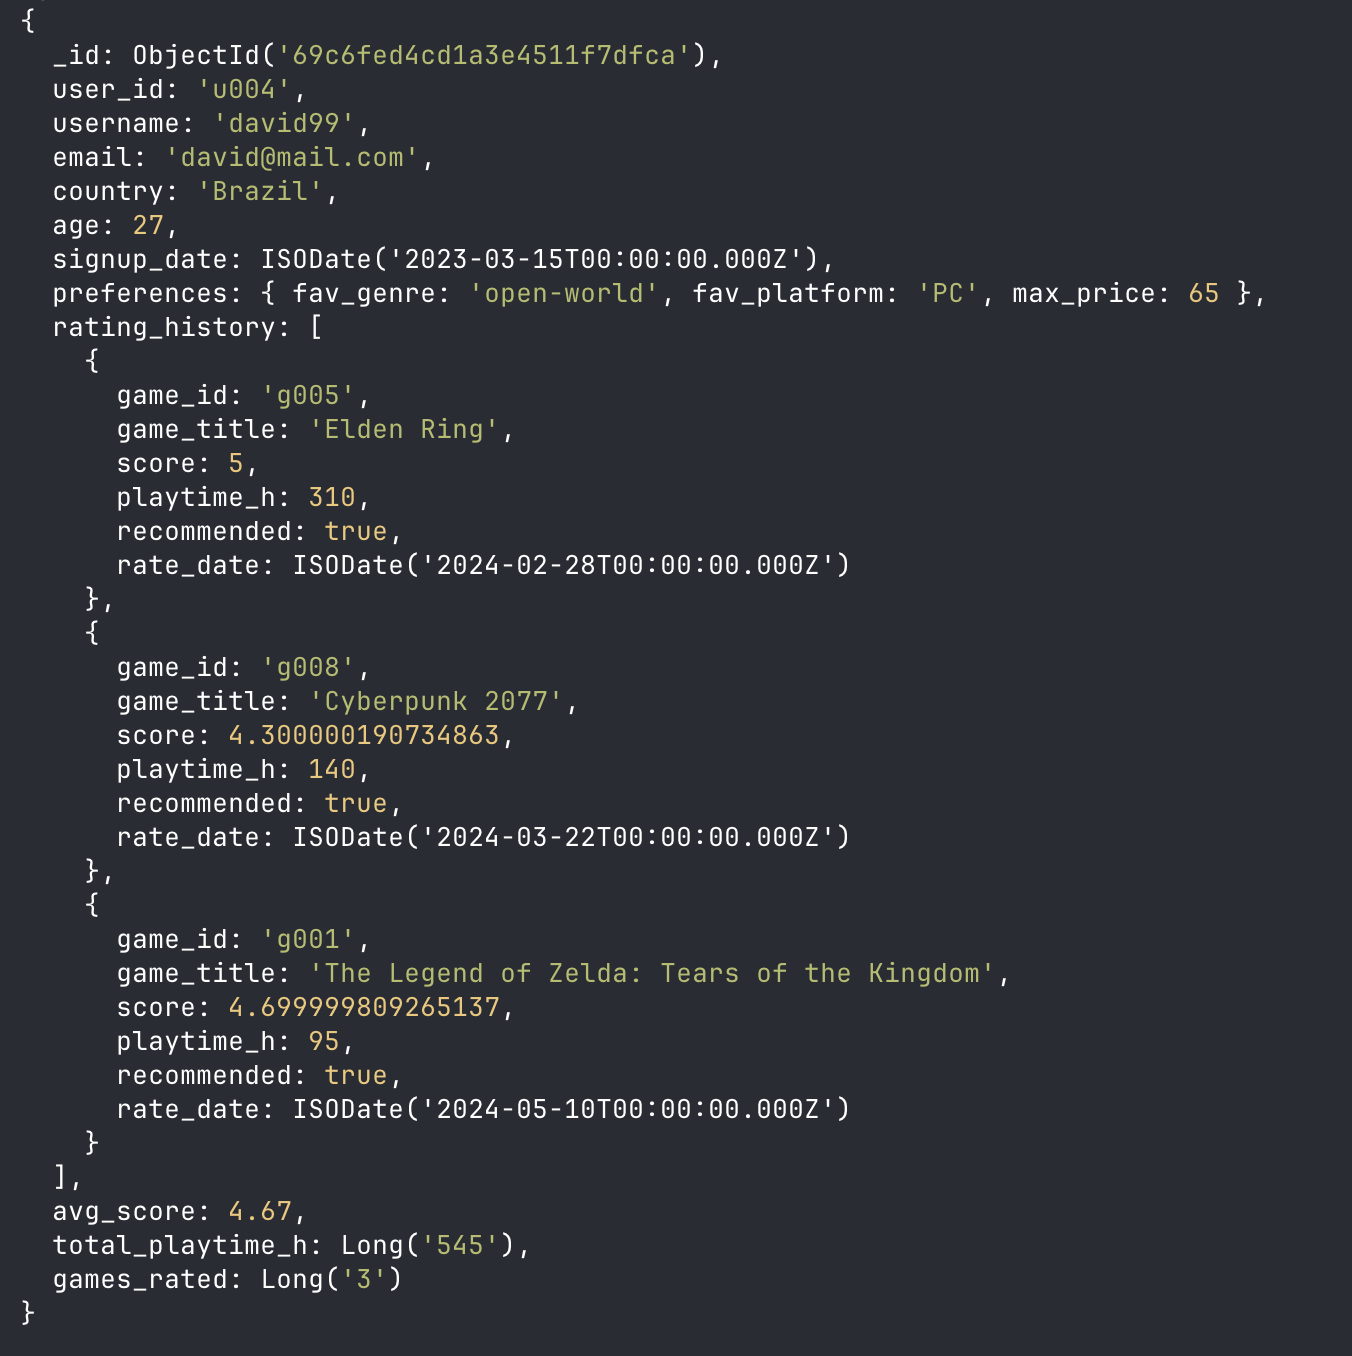

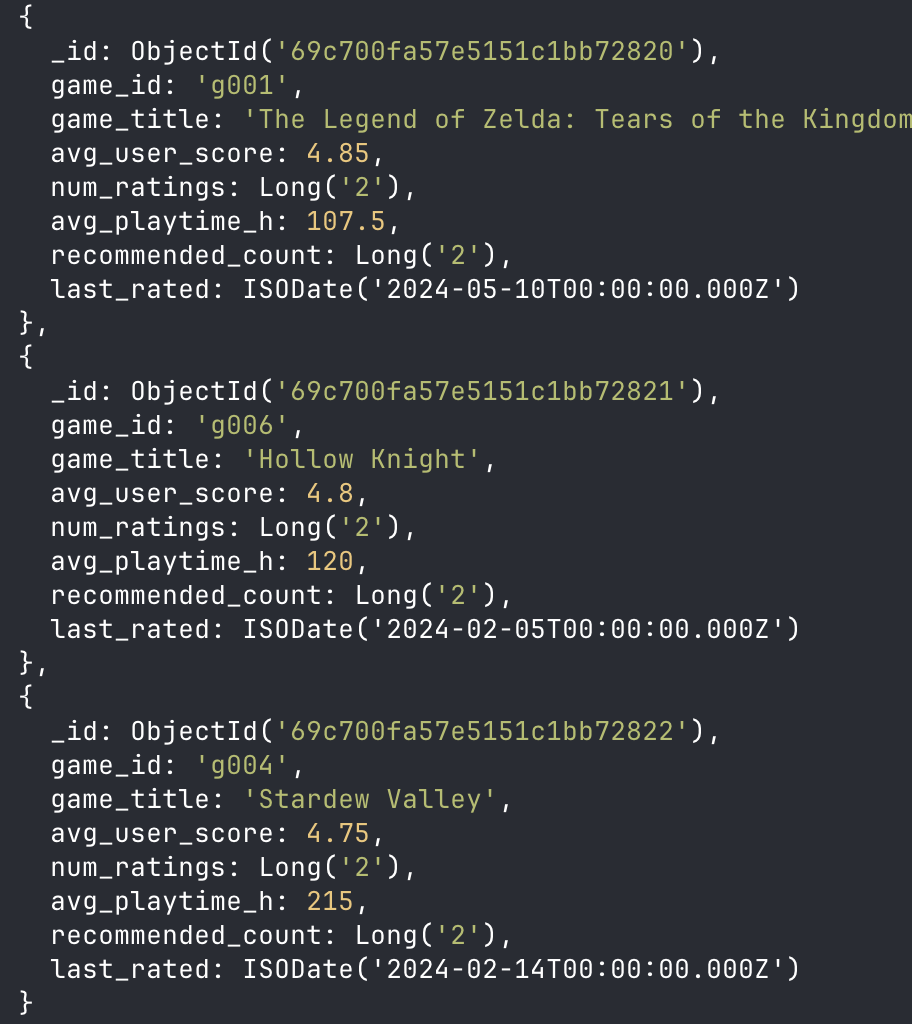

In [ ]:
su.spark.stop()